
Fe (α)
  Number of atoms in unit cell : 2
  Lattice parameter            : 2.870 Å
  Volume                       : 23.640 Å³
  Sites                        : [PeriodicSite: Fe (0.0, 0.0, 0.0) [0.0, 0.0, 0.0], PeriodicSite: Fe (1.435, 1.435, 1.435) [0.5, 0.5, 0.5]]

Fe (γ)
  Number of atoms in unit cell : 4
  Lattice parameter            : 3.656 Å
  Volume                       : 48.867 Å³
  Sites                        : [PeriodicSite: Fe (0.0, 0.0, 0.0) [0.0, 0.0, 0.0], PeriodicSite: Fe (1.828, 1.828, 0.0) [0.5, 0.5, 0.0], PeriodicSite: Fe (1.828, 0.0, 1.828) [0.5, 0.0, 0.5], PeriodicSite: Fe (0.0, 1.828, 1.828) [0.0, 0.5, 0.5]]

Fe (δ)
  Number of atoms in unit cell : 2
  Lattice parameter            : 2.930 Å
  Volume                       : 25.154 Å³
  Sites                        : [PeriodicSite: Fe (0.0, 0.0, 0.0) [0.0, 0.0, 0.0], PeriodicSite: Fe (1.465, 1.465, 1.465) [0.5, 0.5, 0.5]]

Ni
  Number of atoms in unit cell : 4
  Lattice parameter            : 3.524 Å
  Volume     

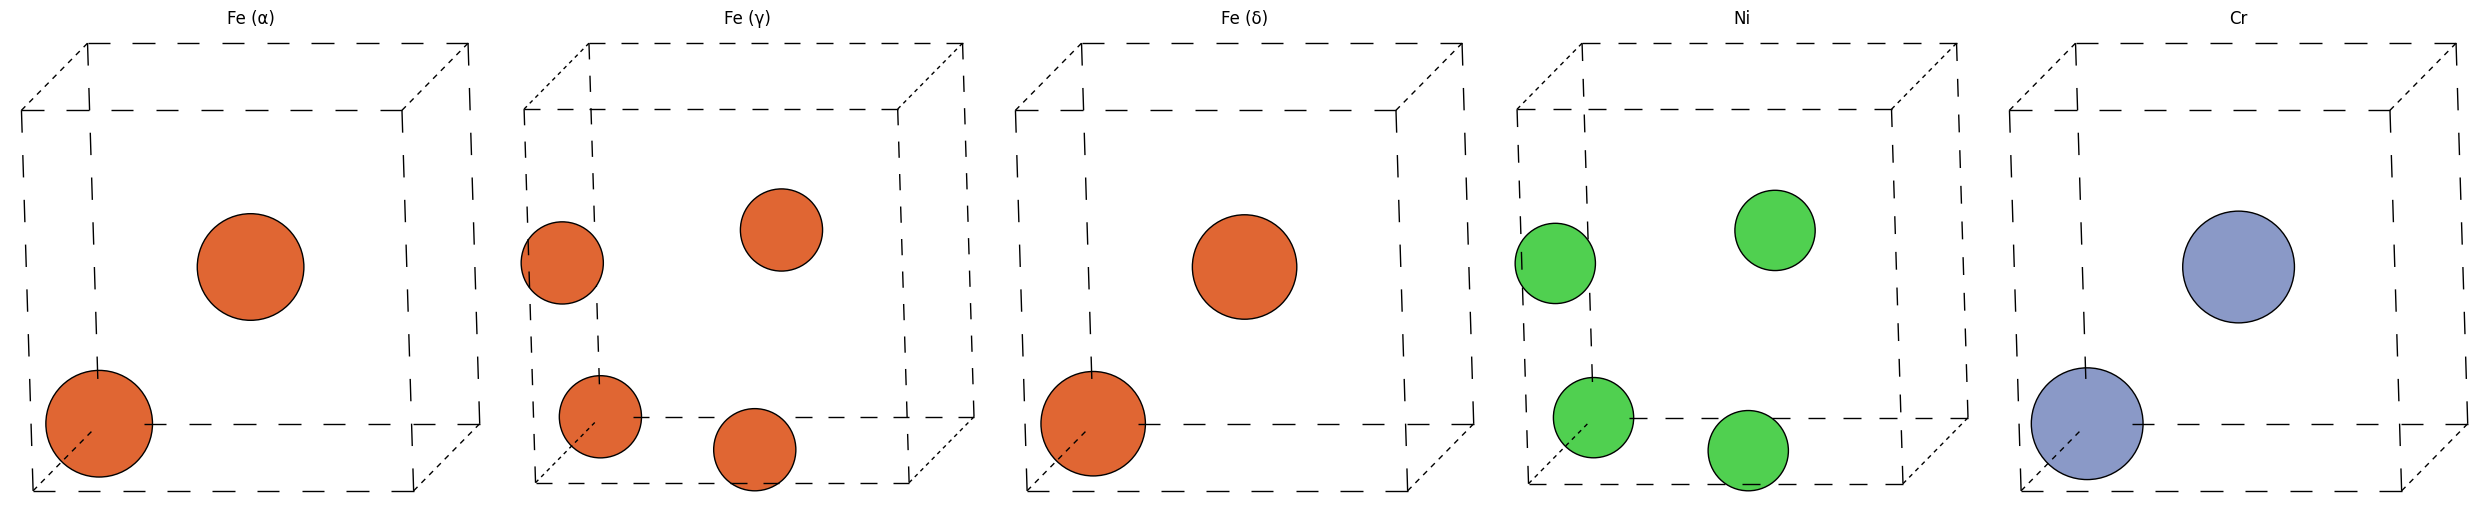


Fe, 0 + Cr, 16 alloy | lattice_a = 2.870 Å

Fe, 4 + Cr, 12 alloy | lattice_a = 2.873 Å

Fe, 8 + Cr, 8 alloy | lattice_a = 2.877 Å

Fe, 12 + Cr, 4 alloy | lattice_a = 2.880 Å

Fe, 16 + Cr, 0 alloy | lattice_a = 2.884 Å

Fe, 0 + Ni, 16 alloy | lattice_a = 2.870 Å

Fe, 4 + Ni, 12 alloy | lattice_a = 3.034 Å

Fe, 8 + Ni, 8 alloy | lattice_a = 3.197 Å

Fe, 12 + Ni, 4 alloy | lattice_a = 3.361 Å

Fe, 16 + Ni, 0 alloy | lattice_a = 3.524 Å

Cr, 0 + Ni, 16 alloy | lattice_a = 2.884 Å

Cr, 4 + Ni, 12 alloy | lattice_a = 3.044 Å

Cr, 8 + Ni, 8 alloy | lattice_a = 3.204 Å

Cr, 12 + Ni, 4 alloy | lattice_a = 3.364 Å

Cr, 16 + Ni, 0 alloy | lattice_a = 3.524 Å


In [56]:
from ase.build import bulk
from ase.visualize.plot import plot_atoms
import matplotlib.pyplot as plt
import numpy as np
from pymatgen.core import Structure, Lattice, Element, Composition
from pymatgen.io.ase import AseAtomsAdaptor
# Structure = the full crystal (lattice + atoms)
# Lattice   = defines the unit cell box (size and shape)
# Element, Composition = tools for working with elements and alloy compositions


# ── UNARY: SINGLE ELEMENTS ───────────────────────────────────────────────────

# Build FCC Nickel using pymatgen
ni = Structure.from_spacegroup("Fm-3m", Lattice.cubic(3.524), ["Ni"], [[0, 0, 0]])
# "Fm-3m": FCC space group, a=3.524 Å

# Build BCC Iron using pymatgen
fe_alpha = Structure.from_spacegroup("Im-3m", Lattice.cubic(2.870), ["Fe"], [[0, 0, 0]])
# "Im-3m": BCC space group, a=2.870 Å when fe is below 912 °C (alpha-Fe)

fe_gamma = Structure.from_spacegroup("Fm-3m", Lattice.cubic(3.656), ["Fe"], [[0, 0, 0]])
# "Fm-3m": FCC space group, a=3.656 Å when fe is above 912 °C (gamma-Fe) and below 1394 °C (delta-Fe)

fe_delta = Structure.from_spacegroup("Im-3m", Lattice.cubic(2.930), ["Fe"], [[0, 0, 0]])
# "Im-3m" Bcc space group, a=2.930 Å when fe is above 1394 °C (delta-Fe)

# Build BCC Chromium using pymatgen
cr = Structure.from_spacegroup("Im-3m", Lattice.cubic(2.884), ["Cr"], [[0, 0, 0]])
# from_spacegroup: builds full crystal using symmetry rules, no need to type every atom
# Lattice.cubic(2.884): defines unit cell box, all sides 2.884 Å, all angles 90°
# ["Cr"]: element placed at the starting position
# [[0,0,0]]: one unique atom position, pymatgen uses Im-3m symmetry to auto-generate
#            the body-centre atom at [0.5, 0.5, 0.5]

structures = [
    ("Fe (α)", fe_alpha),
    ("Fe (γ)", fe_gamma),
    ("Fe (δ)", fe_delta),
    ("Ni",     ni),
    ("Cr",     cr),
]

for name, structure in structures:
    print(f"\n{name}")
    print(f"  Number of atoms in unit cell : {len(structure)}")
    print(f"  Lattice parameter            : {structure.lattice.a:.3f} Å")
    print(f"  Volume                       : {structure.volume:.3f} Å³")
    print(f"  Sites                        : {structure.sites}")
# loops through all 5 print statements for each individual structure

# ── VISUALISATION ─────────────────────────────────────────────────────────────

adaptor = AseAtomsAdaptor()
# Converts pymatgen Structure → ASE Atoms so plot_atoms can render them

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
# 1 row, 5 columns — one subplot per structure

for ax, (name, structure) in zip(axes, structures):
    ase_atoms = adaptor.get_atoms(structure)
    plot_atoms(ase_atoms, ax, radii=0.3, rotation="10x,-10y,0z")
    ax.set_title(name)
# loops through all 5 structures and plots each one

plt.tight_layout()
plt.show()

# Shows the atom positions within one unit cell
# Corner atoms appear as full circles but are shared across 8 neighbouring unit cells (each cell owns 1/8)
# Face atoms are shared across 2 neighbouring unit cells (each cell owns 1/2)
# The visualisation shows position only, not fractional ownership

#── BINARY: TWO-ELEMENT ALLOYS ───────────────────────────────────────────────

# Build BCC Fe-Cr alloy using pymatgen
Lattice_params = {
    "Fe": 2.870,
    "Ni": 3.524,
    "Cr": 2.884
}

space_group = {
    "Fe": "Im-3m",
    "Ni": "Fm-3m",
    "Cr": "Im-3m"
}


def alloy(element1, element2):
    composition = [ 0, 0.25, 0.5, 0.75, 1.0]
    structure = Structure.from_spacegroup(space_group[element1], Lattice.cubic(lattice_params[element1]), [element1], [[0, 0, 0]])
    n_atoms = len(structure.make_supercell([2, 2, 2]))
    n_element1 = [int(n_atoms * x) for x in composition]
    n_element2 = [n_atoms - x for x in n_element1]

    alloy_results = []

    for x, n1, n2 in zip(composition, n_element1, n_element2):
     structure = Structure.from_spacegroup(space_group[element1], Lattice.cubic(lattice_params[element1]), [element1], [[0, 0, 0]])
     supercell = structure.make_supercell([2, 2, 2])
     for i in range(n2):
        supercell.replace(i, element2)
    
     alloy_results.append({
            "system": f"{element1}-{element2}",
            "composition_x": x,
            f"n_{element1}": n1,
            f"n_{element2}": n2,
            "structure": supercell,
            "lattice_a_vegard": Lattice_params[element1] * (1 - x) + Lattice_params[element2] * x,
        })

     print(f"\n{element1}, {n1} + {element2}, {n2} alloy | lattice_a = {Lattice_params[element1] * (1 - x) + Lattice_params[element2] * x:.3f} Å")

alloy("Fe", "Cr")
alloy("Fe", "Ni")
alloy("Cr", "Ni")


